In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
planet_scaled = pd.read_csv(
    "../data/planet_scaled.csv"
)

#### trying to understand no of clusters needed 

In [9]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(planet_scaled)

    inertia.append(
        kmeans.inertia_
    )

print(inertia) #Elbow Method

[11675.668331532292, 7847.148049405785, 6256.589857312409, 5190.5135498169375, 4620.993072893683, 4196.570871500361, 3764.611013536511, 3342.519906592617, 3088.183365902401]


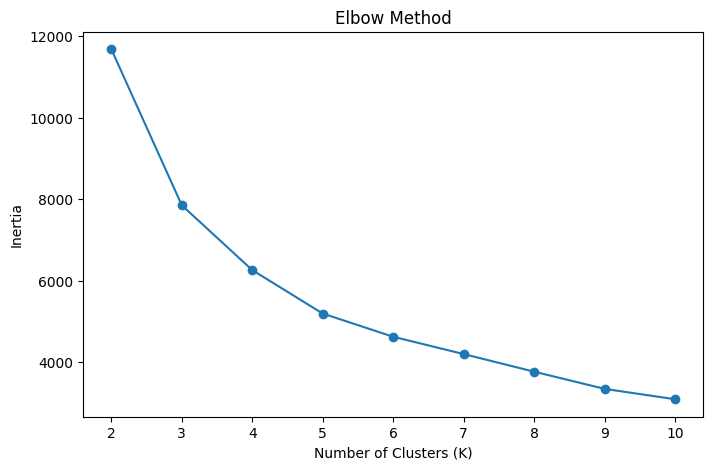

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

k=4 or k=5 most plausible value for k

In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(
        planet_scaled
    )
    score = silhouette_score(
        planet_scaled,
        labels
    )
    silhouette_scores.append(score)

print(silhouette_scores)

[0.5124373624352369, 0.5167026478045886, 0.38503453489916006, 0.3879451180266569, 0.3879858619244323, 0.3355323292670912, 0.33692694822424923, 0.34829812968874346, 0.3392262096811254]


k=3 is most plausible 

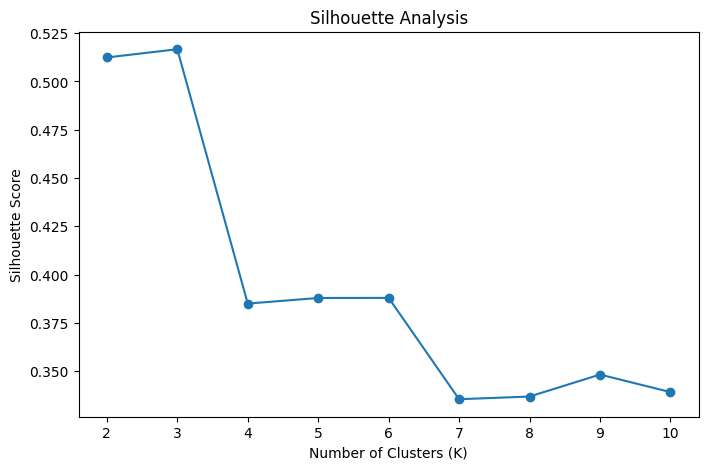

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

creating a clusting model for k-3

In [13]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_3 = kmeans_3.fit_predict(
    planet_scaled
)

clusters_3[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2], dtype=int32)

In [14]:
import pandas as pd

pd.Series(clusters_3).value_counts().sort_index()

0    3544
1    1461
2     728
Name: count, dtype: int64

In [15]:
centers = pd.DataFrame(
    kmeans_3.cluster_centers_,
    columns=planet_scaled.columns
)

centers

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,-0.709690,-0.668066,0.358870,-0.347677
1,1.089833,0.729865,-1.242488,-0.015387
2,1.267713,1.787490,0.746485,1.723418


#### cluster 0
- smaller than avg
- less mass than avg
- sligtly denser than avg
- closer to star than avg

#### cluster 1
- Large radius
- Large mass
- Very low density
- Average orbital distance

#### cluster 2
- large in size
- large mass - massive
- large density 
- farther from the sun

In [19]:
planet_scaled.head()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,1.227724,2.189879,1.761822,1.130717
1,1.236438,2.170099,1.690449,1.281534
2,1.303699,1.583833,0.192650,0.889184
3,1.253655,1.961962,1.178377,1.638133
4,1.335804,1.297996,-0.537079,1.328576


In [23]:
%whos

Variable            Type         Data/Info
------------------------------------------
KMeans              ABCMeta      <class 'sklearn.cluster._kmeans.KMeans'>
StandardScaler      type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
centers             DataFrame    Shape: (3, 4)
clusters_3          ndarray      5733: 5733 elems, type `int32`, 22932 bytes
inertia             list         n=9
k                   int          10
kmeans              KMeans       KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans_3            KMeans       KMeans(n_clusters=3, n_init=10, random_state=42)
labels              ndarray      5733: 5733 elems, type `int32`, 22932 bytes
np                  module       <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                  module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
planet_scaled       DataFrame    Shape: (5733, 4)
plt                 module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.

In [24]:
df = pd.read_csv(
    "../data/PSCompPars.csv",
    comment="#"
)

df.shape

(6298, 320)

In [25]:
planet_features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax"
]

planet_drop = df[planet_features_core].dropna()

planet_drop.shape

(5733, 4)

In [ ]:
# What is the average radius, mass, density, and orbital distance of the planets 
# in each discovered population?

clustered_df = planet_drop.copy()
clustered_df["cluster"] = clusters_3
clustered_df.groupby("cluster").mean()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
cluster,,,,
0,2.155492,11.623982,5.381494,0.157428
1,11.661364,274.778771,0.777044,0.652537
2,12.803188,2561.060134,11.406877,123.675548
